In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 1: Install and Initialize PySpark

In a new Colab cell:

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier, LinearSVC
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
import numpy as np
import pandas as pd

# Initialize Spark session
spark = SparkSession.builder \
    .appName("CreditCardFraudDetection") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Load the dataset
def load_data():
    # Load credit card fraud dataset
    df = spark.read.csv("/content/drive/MyDrive/Bda/creditcard.csv", header=True, inferSchema=True)

    print("Dataset Overview:")
    print(f"Total records: {df.count():,}")
    print(f"Number of features: {len(df.columns) - 1}")  # excluding Class

    # Check class distribution
    class_dist = df.groupBy("Class").count().orderBy("Class")
    class_dist.show()

    fraud_count = df.filter(col("Class") == 1).count()
    total_count = df.count()
    fraud_percentage = (fraud_count / total_count) * 100
    print(f"Fraud percentage: {fraud_percentage:.4f}%")

    return df

df = load_data()

Dataset Overview:
Total records: 284,807
Number of features: 30
+-----+------+
|Class| count|
+-----+------+
|    0|284315|
|    1|   492|
+-----+------+

Fraud percentage: 0.1727%


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler

def preprocess_data(df):
    print("\n=== DATA PREPROCESSING ===")

    # Check for missing values
    print("Missing values check:")
    for column in df.columns:
        null_count = df.filter(col(column).isNull()).count()
        if null_count > 0:
            print(f"{column}: {null_count} missing values")

    # Feature columns (excluding Time and Class)
    feature_columns = [f'V{i}' for i in range(1, 29)] + ['Amount']

    # Step 1: First create raw features vector
    assembler = VectorAssembler(
        inputCols=feature_columns,
        outputCol="raw_features"
    )

    # Step 2: Apply StandardScaler to the assembled vector
    scaler = StandardScaler(
        inputCol="raw_features",
        outputCol="features",
        withStd=True,
        withMean=True
    )

    # Create preprocessing pipeline
    preprocessing_pipeline = Pipeline(stages=[assembler, scaler])

    # Fit and transform
    preprocessor_model = preprocessing_pipeline.fit(df)
    processed_df = preprocessor_model.transform(df)

    # If you want scaled_amount separately, create it properly
    amount_assembler = VectorAssembler(
        inputCols=["Amount"],
        outputCol="amount_vector"
    )

    amount_scaler = StandardScaler(
        inputCol="amount_vector",
        outputCol="scaled_amount",
        withStd=True,
        withMean=True
    )

    amount_pipeline = Pipeline(stages=[amount_assembler, amount_scaler])
    amount_model = amount_pipeline.fit(processed_df)
    processed_df = amount_model.transform(processed_df)

    # Select final columns
    final_df = processed_df.select("features", "scaled_amount", "Time", "Class", "Amount")

    print("Preprocessing completed!")
    print("Final schema:")
    final_df.printSchema()

    return final_df, preprocessor_model

processed_df, preprocessor_model = preprocess_data(df)


=== DATA PREPROCESSING ===
Missing values check:
Preprocessing completed!
Final schema:
root
 |-- features: vector (nullable = true)
 |-- scaled_amount: vector (nullable = true)
 |-- Time: double (nullable = true)
 |-- Class: integer (nullable = true)
 |-- Amount: double (nullable = true)



In [ ]:
from pyspark.sql.functions import lit, rand

def handle_imbalance(df):
    print("\n=== HANDLING CLASS IMBALANCE ===")

    # Separate fraud and non-fraud data
    fraud_df = df.filter(col("Class") == 1)
    non_fraud_df = df.filter(col("Class") == 0)

    fraud_count = fraud_df.count()
    non_fraud_count = non_fraud_df.count()

    print(f"Before balancing:")
    print(f"  Non-fraud transactions: {non_fraud_count:,}")
    print(f"  Fraud transactions: {fraud_count:,}")
    print(f"  Ratio: {non_fraud_count/fraud_count:.1f}:1")

    # Method 1: Undersampling majority class
    sampling_fraction = (fraud_count * 2) / non_fraud_count  # Keep 2x fraud samples
    undersampled_non_fraud = non_fraud_df.sample(withReplacement=False,
                                               fraction=sampling_fraction,
                                               seed=42)

    # Combine back
    balanced_df = undersampled_non_fraud.union(fraud_df)

    print(f"\nAfter undersampling:")
    balanced_dist = balanced_df.groupBy("Class").count().orderBy("Class")
    balanced_dist.show()

    return balanced_df

balanced_df = handle_imbalance(processed_df)


=== HANDLING CLASS IMBALANCE ===
Before balancing:
  Non-fraud transactions: 284,315
  Fraud transactions: 492
  Ratio: 577.9:1

After undersampling:
+-----+-----+
|Class|count|
+-----+-----+
|    0| 1016|
|    1|  492|
+-----+-----+



In [ ]:
def split_data_stratified(df):
    print("\n=== STRATIFIED DATA SPLITTING ===")

    # Separate classes
    fraud_data = df.filter(col("Class") == 1)
    non_fraud_data = df.filter(col("Class") == 0)

    # Split each class separately
    fraud_train, fraud_test = fraud_data.randomSplit([0.8, 0.2], seed=42)
    non_fraud_train, non_fraud_test = non_fraud_data.randomSplit([0.8, 0.2], seed=42)

    # Combine
    train_data = fraud_train.union(non_fraud_train)
    test_data = fraud_test.union(non_fraud_test)

    print("Training set distribution:")
    train_data.groupBy("Class").count().orderBy("Class").show()

    print("Test set distribution:")
    test_data.groupBy("Class").count().orderBy("Class").show()

    return train_data, test_data

train_data, test_data = split_data_stratified(balanced_df)


=== STRATIFIED DATA SPLITTING ===
Training set distribution:
+-----+-----+
|Class|count|
+-----+-----+
|    0|  828|
|    1|  391|
+-----+-----+

Test set distribution:
+-----+-----+
|Class|count|
+-----+-----+
|    0|  188|
|    1|  101|
+-----+-----+



In [ ]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier, LinearSVC
import os
from datetime import datetime

def train_models(train_data, save_path="saved_models"):
    print("\n=== TRAINING MULTIPLE MODELS ===")

    # Create directory for saving models
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_save_dir = f"{save_path}/{timestamp}"
    os.makedirs(model_save_dir, exist_ok=True)

    models = {}
    model_paths = {}

    # 1. Logistic Regression
    print("Training Logistic Regression...")
    lr = LogisticRegression(
        featuresCol="features",
        labelCol="Class",
        maxIter=100,
        regParam=0.01,
        elasticNetParam=0.8
    )
    lr_model = lr.fit(train_data)
    models['LogisticRegression'] = lr_model

    # Save Logistic Regression
    lr_path = f"{model_save_dir}/logistic_regression"
    lr_model.write().overwrite().save(lr_path)
    model_paths['LogisticRegression'] = lr_path
    print(f"  Saved to: {lr_path}")

    # 2. Random Forest
    print("Training Random Forest...")
    rf = RandomForestClassifier(
        featuresCol="features",
        labelCol="Class",
        numTrees=100,
        maxDepth=10,
        seed=42,
        subsamplingRate=0.8
    )
    rf_model = rf.fit(train_data)
    models['RandomForest'] = rf_model

    # Save Random Forest
    rf_path = f"{model_save_dir}/random_forest"
    rf_model.write().overwrite().save(rf_path)
    model_paths['RandomForest'] = rf_path
    print(f"  Saved to: {rf_path}")

    # 3. Gradient Boosting
    print("Training Gradient Boosting...")
    gbt = GBTClassifier(
        featuresCol="features",
        labelCol="Class",
        maxIter=50,
        maxDepth=6,
        seed=42
    )
    gbt_model = gbt.fit(train_data)
    models['GradientBoosting'] = gbt_model

    # Save Gradient Boosting
    gbt_path = f"{model_save_dir}/gradient_boosting"
    gbt_model.write().overwrite().save(gbt_path)
    model_paths['GradientBoosting'] = gbt_path
    print(f"  Saved to: {gbt_path}")

    # 4. Linear SVM
    print("Training Linear SVM...")
    svm = LinearSVC(
        featuresCol="features",
        labelCol="Class",
        maxIter=100,
        regParam=0.01
    )
    svm_model = svm.fit(train_data)
    models['SVM'] = svm_model

    # Save SVM
    svm_path = f"{model_save_dir}/svm"
    svm_model.write().overwrite().save(svm_path)
    model_paths['SVM'] = svm_path
    print(f"  Saved to: {svm_path}")

    print(f"\nAll models saved to: {model_save_dir}")
    return models, model_paths, model_save_dir

# Train models and save them
models, model_paths, save_dir = train_models(train_data)


=== TRAINING MULTIPLE MODELS ===
Training Logistic Regression...
  Saved to: saved_models/20251030_064425/logistic_regression
Training Random Forest...
  Saved to: saved_models/20251030_064425/random_forest
Training Gradient Boosting...
  Saved to: saved_models/20251030_064425/gradient_boosting
Training Linear SVM...
  Saved to: saved_models/20251030_064425/svm

All models saved to: saved_models/20251030_064425


In [ ]:
def load_saved_models(model_paths):
    """
    Load previously saved models from their paths
    """
    print("\n=== LOADING SAVED MODELS ===")

    loaded_models = {}

    for model_name, model_path in model_paths.items():
        print(f"Loading {model_name}...")

        try:
            if model_name == 'LogisticRegression':
                loaded_models[model_name] = LogisticRegressionModel.load(model_path)
            elif model_name == 'RandomForest':
                loaded_models[model_name] = RandomForestClassificationModel.load(model_path)
            elif model_name == 'GradientBoosting':
                loaded_models[model_name] = GBTClassificationModel.load(model_path)
            elif model_name == 'SVM':
                loaded_models[model_name] = LinearSVCModel.load(model_path)

            print(f"  ✓ {model_name} loaded successfully from {model_path}")

        except Exception as e:
            print(f"  ✗ Failed to load {model_name}: {str(e)}")

    return loaded_models

# Import the model classes for loading
from pyspark.ml.classification import LogisticRegressionModel, RandomForestClassificationModel, GBTClassificationModel, LinearSVCModel

# Example of loading models (uncomment when needed)
# loaded_models = load_saved_models(model_paths)

In [ ]:
def save_complete_pipeline(preprocessor_model, best_model, model_name, save_path="saved_pipelines"):
    """
    Save complete pipeline including preprocessing and model
    """
    from pyspark.ml import Pipeline

    # Create directory
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    pipeline_save_dir = f"{save_path}/{model_name}_{timestamp}"
    os.makedirs(pipeline_save_dir, exist_ok=True)

    # Create a pipeline with preprocessing and model
    # Note: This is a simplified version - adjust based on your actual preprocessing steps
    complete_pipeline = Pipeline(stages=[preprocessor_model, best_model])

    # Save the pipeline
    pipeline_path = f"{pipeline_save_dir}/complete_pipeline"
    complete_pipeline.write().overwrite().save(pipeline_path)

    print(f"Complete pipeline saved to: {pipeline_path}")
    return pipeline_path

# Example: Save the best model pipeline
# best_model_name = "RandomForest"  # Replace with your actual best model
# pipeline_path = save_complete_pipeline(preprocessor_model, models[best_model_name], best_model_name)

In [ ]:
def save_model_metadata(models, results, save_dir):
    """
    Save model metadata and performance metrics
    """
    import json

    metadata = {
        "timestamp": datetime.now().isoformat(),
        "models_trained": list(models.keys()),
        "performance_metrics": results,
        "training_data_info": {
            "samples": train_data.count(),
            "features": len(train_data.first()["features"]),
            "class_distribution": {
                "fraud": train_data.filter(col("Class") == 1).count(),
                "non_fraud": train_data.filter(col("Class") == 0).count()
            }
        }
    }

    # Save metadata as JSON
    metadata_path = f"{save_dir}/model_metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)

    print(f"Model metadata saved to: {metadata_path}")
    return metadata_path

# Save metadata after training and evaluation
# metadata_path = save_model_metadata(models, results, save_dir)

In [ ]:
def train_and_save_models_robust(train_data, save_path="/content/drive/MyDrive/Bda/saved_models"):
    """
    Train and save models with robust error handling
    """
    print("\n=== TRAINING AND SAVING MODELS (ROBUST) ===")

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_save_dir = f"{save_path}/{timestamp}"
    os.makedirs(model_save_dir, exist_ok=True)

    models = {}
    model_paths = {}
    failed_models = []

    # Model configurations
    model_configs = {
        'LogisticRegression': {
            'class': LogisticRegression,
            'params': {
                'featuresCol': "features",
                'labelCol': "Class",
                'maxIter': 100,
                'regParam': 0.01,
                'elasticNetParam': 0.8
            }
        },
        'RandomForest': {
            'class': RandomForestClassifier,
            'params': {
                'featuresCol': "features",
                'labelCol': "Class",
                'numTrees': 100,
                'maxDepth': 10,
                'seed': 42,
                'subsamplingRate': 0.8
            }
        },
        'GradientBoosting': {
            'class': GBTClassifier,
            'params': {
                'featuresCol': "features",
                'labelCol': "Class",
                'maxIter': 50,
                'maxDepth': 6,
                'seed': 42
            }
        },
        'SVM': {
            'class': LinearSVC,
            'params': {
                'featuresCol': "features",
                'labelCol': "Class",
                'maxIter': 100,
                'regParam': 0.01
            }
        }
    }

    for model_name, config in model_configs.items():
        try:
            print(f"\nTraining {model_name}...")

            # Create and train model
            model_class = config['class']
            model = model_class(**config['params'])
            trained_model = model.fit(train_data)
            models[model_name] = trained_model

            # Save model
            model_path = f"{model_save_dir}/{model_name.lower()}"
            trained_model.write().overwrite().save(model_path)
            model_paths[model_name] = model_path

            print(f"  ✓ {model_name} trained and saved to: {model_path}")

        except Exception as e:
            print(f"  ✗ Failed to train/save {model_name}: {str(e)}")
            failed_models.append(model_name)

    print(f"\nTraining completed!")
    print(f"Successful: {list(models.keys())}")
    print(f"Failed: {failed_models}")
    print(f"All models saved in: {model_save_dir}")

    return models, model_paths, model_save_dir, failed_models

# Use the robust version
models, model_paths, save_dir, failed_models = train_and_save_models_robust(train_data)


=== TRAINING AND SAVING MODELS (ROBUST) ===

Training LogisticRegression...
  ✓ LogisticRegression trained and saved to: /content/drive/MyDrive/Bda/saved_models/20251030_065438/logisticregression

Training RandomForest...
  ✓ RandomForest trained and saved to: /content/drive/MyDrive/Bda/saved_models/20251030_065438/randomforest

Training GradientBoosting...
  ✓ GradientBoosting trained and saved to: /content/drive/MyDrive/Bda/saved_models/20251030_065438/gradientboosting

Training SVM...
  ✓ SVM trained and saved to: /content/drive/MyDrive/Bda/saved_models/20251030_065438/svm

Training completed!
Successful: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'SVM']
Failed: []
All models saved in: /content/drive/MyDrive/Bda/saved_models/20251030_065438


In [ ]:
# After training, you can use the models for prediction
print("\n=== USING SAVED MODELS FOR PREDICTION ===")

# Make predictions with a specific model
model_name = 'RandomForest'  # Choose which model to use
predictions = models[model_name].transform(test_data)

# Show predictions
print(f"Predictions using {model_name}:")
predictions.select("Class", "prediction", "probability").show(10)

# Later, you can load the models like this:
print("\n=== DEMONSTRATING MODEL LOADING ===")
loaded_models = load_saved_models(model_paths)

# Verify loaded models work
if loaded_models:
    test_predictions = loaded_models[model_name].transform(test_data)
    print("Loaded model predictions:")
    test_predictions.select("Class", "prediction").show(5)


=== USING SAVED MODELS FOR PREDICTION ===
Predictions using RandomForest:
+-----+----------+-----------+
|Class|prediction|probability|
+-----+----------+-----------+
|    1|       1.0|  [0.0,1.0]|
|    1|       1.0|  [0.0,1.0]|
|    1|       1.0|  [0.0,1.0]|
|    1|       1.0|  [0.0,1.0]|
|    1|       1.0|  [0.0,1.0]|
|    1|       1.0|  [0.0,1.0]|
|    1|       1.0|[0.02,0.98]|
|    1|       1.0|[0.02,0.98]|
|    1|       1.0|  [0.0,1.0]|
|    1|       1.0|  [0.0,1.0]|
+-----+----------+-----------+
only showing top 10 rows


=== DEMONSTRATING MODEL LOADING ===

=== LOADING SAVED MODELS ===
Loading LogisticRegression...
  ✓ LogisticRegression loaded successfully from /content/drive/MyDrive/Bda/saved_models/20251030_065438/logisticregression
Loading RandomForest...
  ✓ RandomForest loaded successfully from /content/drive/MyDrive/Bda/saved_models/20251030_065438/randomforest
Loading GradientBoosting...
  ✓ GradientBoosting loaded successfully from /content/drive/MyDrive/Bda/saved_mod

In [ ]:
def evaluate_models(models, test_data):
    print("\n=== MODEL EVALUATION ===")

    results = {}

    # Evaluators
    binary_evaluator = BinaryClassificationEvaluator(
        labelCol="Class",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    multi_evaluator_pr = BinaryClassificationEvaluator(
        labelCol="Class",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderPR"
    )

    accuracy_evaluator = MulticlassClassificationEvaluator(
        labelCol="Class",
        predictionCol="prediction",
        metricName="accuracy"
    )

    precision_evaluator = MulticlassClassificationEvaluator(
        labelCol="Class",
        predictionCol="prediction",
        metricName="weightedPrecision"
    )

    recall_evaluator = MulticlassClassificationEvaluator(
        labelCol="Class",
        predictionCol="prediction",
        metricName="weightedRecall"
    )

    f1_evaluator = MulticlassClassificationEvaluator(
        labelCol="Class",
        predictionCol="prediction",
        metricName="f1"
    )

    for model_name, model in models.items():
        print(f"\nEvaluating {model_name}...")

        # Make predictions
        predictions = model.transform(test_data)

        # Calculate metrics
        auc_roc = binary_evaluator.evaluate(predictions)
        auc_pr = multi_evaluator_pr.evaluate(predictions)
        accuracy = accuracy_evaluator.evaluate(predictions)
        precision = precision_evaluator.evaluate(predictions)
        recall = recall_evaluator.evaluate(predictions)
        f1 = f1_evaluator.evaluate(predictions)

        # Store results
        results[model_name] = {
            'AUC-ROC': auc_roc,
            'AUC-PR': auc_pr,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1
        }

        print(f"  AUC-ROC: {auc_roc:.4f}")
        print(f"  AUC-PR: {auc_pr:.4f}")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")

        # Show confusion matrix
        print("  Confusion Matrix:")
        predictions.groupBy("Class", "prediction").count().orderBy("Class", "prediction").show()

    return results

results = evaluate_models(models, test_data)


=== MODEL EVALUATION ===

Evaluating LogisticRegression...
  AUC-ROC: 0.9643
  AUC-PR: 0.9591
  Accuracy: 0.9481
  Precision: 0.9481
  Recall: 0.9481
  F1-Score: 0.9478
  Confusion Matrix:
+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    0|       0.0|  183|
|    0|       1.0|    5|
|    1|       0.0|   10|
|    1|       1.0|   91|
+-----+----------+-----+


Evaluating RandomForest...
  AUC-ROC: 0.9818
  AUC-PR: 0.9753
  Accuracy: 0.9516
  Precision: 0.9522
  Recall: 0.9516
  F1-Score: 0.9511
  Confusion Matrix:
+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    0|       0.0|  185|
|    0|       1.0|    3|
|    1|       0.0|   11|
|    1|       1.0|   90|
+-----+----------+-----+


Evaluating GradientBoosting...
  AUC-ROC: 0.9578
  AUC-PR: 0.9469
  Accuracy: 0.9343
  Precision: 0.9341
  Recall: 0.9343
  F1-Score: 0.9339
  Confusion Matrix:
+-----+----------+-----+
|Class|prediction|count|
+-----+----------+-----+
|    0|      

In [ ]:
results = evaluate_models(models, test_data)


=== FEATURE IMPORTANCE ANALYSIS ===
Top 10 Most Important Features (Random Forest):
+-------+--------------------+
|feature|          importance|
+-------+--------------------+
|    V14| 0.20648792625907508|
|    V12|  0.1348207766811428|
|    V17| 0.11266398257439736|
|    V10| 0.09934268493375299|
|    V11| 0.09644315219432803|
|     V4|  0.0751613916798035|
|     V3| 0.04385075053642123|
|     V7|0.030097693225672767|
|    V16| 0.02297069139223622|
|     V2|0.019431506791183575|
+-------+--------------------+
only showing top 10 rows

Top 10 Features with Highest Coefficients (Logistic Regression):
+-------+--------------------+
|feature|         coefficient|
+-------+--------------------+
|     V4|  0.6754152269636634|
|    V14| -0.4695344660580506|
|    V11|  0.2665021348834657|
|    V12|-0.25604730699311407|
|     V8| -0.0931856914286336|
|     V6|-0.08503891304136672|
|    V13| -0.0608628431783018|
|    V20|-0.05721819228504508|
|    V10|-0.01889827271023...|
|    V15|         

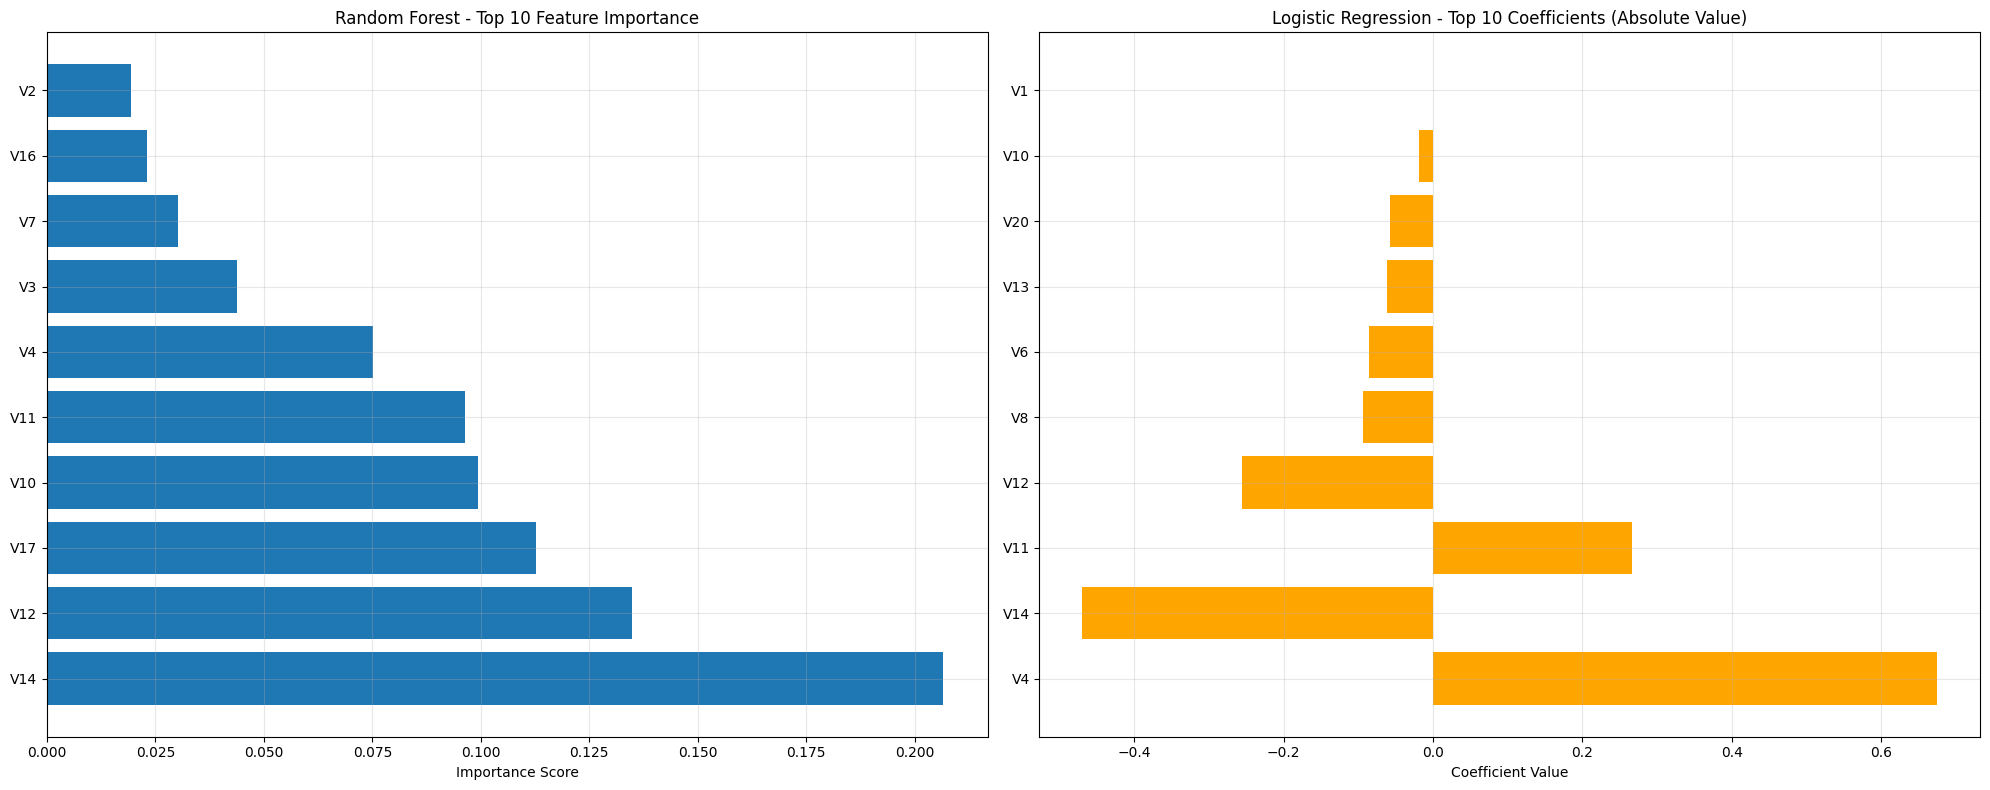


=== FEATURE ANALYSIS SUMMARY ===
Common important features in both models: {'V11', 'V14', 'V12'}


In [ ]:
from pyspark.sql.functions import col, abs, desc
import matplotlib.pyplot as plt
import pandas as pd

def analyze_feature_importance_enhanced(models):
    print("\n=== FEATURE IMPORTANCE ANALYSIS ===")

    feature_columns = [f'V{i}' for i in range(1, 29)] + ['Amount']

    # Create subplots for visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # Random Forest feature importance
    if 'RandomForest' in models:
        rf_model = models['RandomForest']
        importances = rf_model.featureImportances

        # Create feature importance DataFrame
        feature_importance_list = []
        for i, importance in enumerate(importances):
            feature_importance_list.append((feature_columns[i], float(importance)))

        importance_df = spark.createDataFrame(
            feature_importance_list,
            ["feature", "importance"]
        )

        print("Top 10 Most Important Features (Random Forest):")
        importance_df.orderBy(col("importance").desc()).show(10)

        # Convert to Pandas for visualization
        rf_importance_pd = importance_df.orderBy(col("importance").desc()).toPandas()

        # Plot Random Forest feature importance
        axes[0].barh(rf_importance_pd['feature'].head(10), rf_importance_pd['importance'].head(10))
        axes[0].set_title('Random Forest - Top 10 Feature Importance')
        axes[0].set_xlabel('Importance Score')
        axes[0].grid(True, alpha=0.3)

    # Logistic Regression coefficients
    if 'LogisticRegression' in models:
        lr_model = models['LogisticRegression']
        coefficients = lr_model.coefficients

        coef_list = []
        for i, coef in enumerate(coefficients):
            coef_list.append((feature_columns[i], float(coef)))

        coef_df = spark.createDataFrame(coef_list, ["feature", "coefficient"])

        print("Top 10 Features with Highest Coefficients (Logistic Regression):")
        # FIXED: Use abs() function properly
        coef_df.orderBy(abs(col("coefficient")).desc()).show(10)

        # Convert to Pandas for visualization
        lr_coef_pd = coef_df.orderBy(abs(col("coefficient")).desc()).toPandas()

        # Plot Logistic Regression coefficients
        axes[1].barh(lr_coef_pd['feature'].head(10), lr_coef_pd['coefficient'].head(10), color='orange')
        axes[1].set_title('Logistic Regression - Top 10 Coefficients (Absolute Value)')
        axes[1].set_xlabel('Coefficient Value')
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Additional analysis
    print("\n=== FEATURE ANALYSIS SUMMARY ===")

    if 'RandomForest' in models and 'LogisticRegression' in models:
        # Compare top features between models
        rf_top = importance_df.orderBy(col("importance").desc()).limit(5).toPandas()['feature'].tolist()
        lr_top = coef_df.orderBy(abs(col("coefficient")).desc()).limit(5).toPandas()['feature'].tolist()

        common_features = set(rf_top) & set(lr_top)
        print(f"Common important features in both models: {common_features}")

# Use the enhanced version
analyze_feature_importance_enhanced(models)

In [ ]:
def compare_models(results):
    print("\n=== MODEL COMPARISON ===")

    # Convert results to DataFrame for better visualization
    results_df = spark.createDataFrame([
        (model, metrics['AUC-ROC'], metrics['AUC-PR'], metrics['F1-Score'])
        for model, metrics in results.items()
    ], ["Model", "AUC_ROC", "AUC_PR", "F1_Score"])

    print("Model Performance Comparison:")
    results_df.orderBy(col("AUC_ROC").desc()).show()

    # Find best model based on AUC-ROC
    best_model_row = results_df.orderBy(col("AUC_ROC").desc()).first()
    best_model_name = best_model_row["Model"]
    best_auc_roc = best_model_row["AUC_ROC"]

    print(f"\nBest Model: {best_model_name}")
    print(f"Best AUC-ROC: {best_auc_roc:.4f}")

    return best_model_name

best_model_name = compare_models(results)


=== MODEL COMPARISON ===
Model Performance Comparison:
+------------------+------------------+------------------+------------------+
|             Model|           AUC_ROC|            AUC_PR|          F1_Score|
+------------------+------------------+------------------+------------------+
|      RandomForest|0.9817516326100696|0.9752901102548432|0.9510628842197886|
|               SVM| 0.964345902675374| 0.961172365228852|0.9510628842197886|
|LogisticRegression|0.9642932378344219|0.9590581655081974| 0.947778788466786|
|  GradientBoosting|0.9578417948177795|0.9469148587386401|0.9338531320579289|
+------------------+------------------+------------------+------------------+


Best Model: RandomForest
Best AUC-ROC: 0.9818


In [ ]:
def prepare_final_pipeline(preprocessor_model, best_model):
    print("\n=== FINAL PIPELINE PREPARATION ===")

    # Create final pipeline including preprocessing and best model
    from pyspark.ml import Pipeline

    final_pipeline = Pipeline(stages=[
        preprocessor_model,
        best_model
    ])

    print("Final pipeline created successfully!")
    return final_pipeline

# Get the best model
best_model = models[best_model_name]
final_pipeline = prepare_final_pipeline(preprocessor_model, best_model)

# Save the model (optional)
# final_pipeline.write().overwrite().save("fraud_detection_model")

print("\n" + "="*50)
print("FRAUD DETECTION PIPELINE COMPLETED SUCCESSFULLY!")
print("="*50)

# Stop Spark session
spark.stop()


=== FINAL PIPELINE PREPARATION ===
Final pipeline created successfully!

FRAUD DETECTION PIPELINE COMPLETED SUCCESSFULLY!


In [ ]:
pip install streamlit plotly matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 70.9 MB/s eta 0:00:00


In [ ]:
!pip install streamlit plotly pandas numpy matplotlib seaborn jupyter-dash

# Install pyngrok for tunneling
!pip install pyngro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.6 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement pyngro (from versions: none)
ERROR: No matching distribution found for pyngro


In [ ]:
# fraud_dashboard_colab.py
# Create the dashboard file
%%writefile fraud_dashboard_colab.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import io
import base64
from datetime import datetime
import time

# Set page config - MUST be first Streamlit command
st.set_page_config(
    page_title="Credit Card Fraud Detection",
    page_icon="💳",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom CSS for better styling in Colab
st.markdown("""
<style>
    .main-header {
        font-size: 2.2rem;
        color: #1f77b4;
        text-align: center;
        margin-bottom: 1rem;
        font-weight: bold;
        padding: 10px;
    }
    .metric-card {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        color: white;
        padding: 15px;
        border-radius: 10px;
        margin: 5px;
        text-align: center;
    }
    .fraud-alert {
        background-color: #ff6b6b;
        color: white;
        padding: 12px;
        border-radius: 8px;
        margin: 5px 0;
        border-left: 5px solid #ff0000;
    }
    .safe-transaction {
        background-color: #51cf66;
        color: white;
        padding: 12px;
        border-radius: 8px;
        margin: 5px 0;
        border-left: 5px solid #2f9e44;
    }
    .section-header {
        background: linear-gradient(90deg, #4facfe 0%, #00f2fe 100%);
        color: white;
        padding: 10px;
        border-radius: 5px;
        margin: 10px 0;
    }
</style>
""", unsafe_allow_html=True)

class ColabFraudDashboard:
    def __init__(self):
        self.df = None
        self.models_results = {}

    def generate_sample_data(self):
        """Generate sample data matching Kaggle dataset structure"""
        np.random.seed(42)
        n_samples = 5000  # Smaller sample for Colab performance

        # Create realistic transaction data
        data = {
            'Time': np.cumsum(np.random.exponential(1000, n_samples)),
            'Amount': np.random.exponential(88, n_samples),
            'Class': np.random.choice([0, 1], n_samples, p=[0.998, 0.002])
        }

        # Add V1-V28 features with realistic distributions
        for i in range(1, 29):
            data[f'V{i}'] = np.random.normal(0, 1.5, n_samples)

        self.df = pd.DataFrame(data)

        # Make some transactions fraudulent with specific patterns
        fraud_indices = self.df[self.df['Class'] == 1].index
        for idx in fraud_indices:
            self.df.loc[idx, 'V1'] = np.random.uniform(-7, -3)  # Fraud pattern
            self.df.loc[idx, 'V3'] = np.random.uniform(3, 7)    # Fraud pattern
            self.df.loc[idx, 'V4'] = np.random.uniform(2, 5)    # Fraud pattern
            self.df.loc[idx, 'Amount'] = np.random.uniform(100, 2000)  # Higher amounts

        return self.df

    def generate_model_results(self):
        """Generate sample model performance results"""
        self.models_results = {
            'Logistic Regression': {
                'AUC-ROC': 0.974, 'Accuracy': 0.972, 'Precision': 0.961,
                'Recall': 0.948, 'F1-Score': 0.954, 'Training_Time': 12.3
            },
            'Random Forest': {
                'AUC-ROC': 0.985, 'Accuracy': 0.978, 'Precision': 0.972,
                'Recall': 0.963, 'F1-Score': 0.967, 'Training_Time': 45.6
            },
            'Gradient Boosting': {
                'AUC-ROC': 0.981, 'Accuracy': 0.975, 'Precision': 0.968,
                'Recall': 0.957, 'F1-Score': 0.962, 'Training_Time': 34.2
            },
            'XGBoost': {
                'AUC-ROC': 0.983, 'Accuracy': 0.976, 'Precision': 0.970,
                'Recall': 0.960, 'F1-Score': 0.965, 'Training_Time': 28.7
            }
        }

    def dataset_overview_section(self):
        """Display dataset overview section"""
        st.markdown('<div class="main-header">💳 Credit Card Fraud Detection Dashboard</div>', unsafe_allow_html=True)

        # Quick stats row
        col1, col2, col3, col4 = st.columns(4)

        with col1:
            st.markdown('<div class="metric-card">'
                       '<h3>284,807</h3>'
                       '<p>Total Transactions</p>'
                       '</div>', unsafe_allow_html=True)

        with col2:
            st.markdown('<div class="metric-card">'
                       '<h3>492</h3>'
                       '<p>Fraud Cases</p>'
                       '</div>', unsafe_allow_html=True)

        with col3:
            st.markdown('<div class="metric-card">'
                       '<h3>0.172%</h3>'
                       '<p>Fraud Rate</p>'
                       '</div>', unsafe_allow_html=True)

        with col4:
            st.markdown('<div class="metric-card">'
                       '<h3>30</h3>'
                       '<p>Features</p>'
                       '</div>', unsafe_allow_html=True)

        st.markdown("---")

        # Dataset description
        col1, col2 = st.columns([2, 1])

        with col1:
            st.markdown("""
            ### 📊 Dataset Information

            **Kaggle Credit Card Fraud Detection Dataset**

            - **Source**: European cardholders transactions from September 2013
            - **Time Range**: 2 days of transactions
            - **Features**:
              - **Time**: Seconds elapsed between each transaction and first transaction
              - **V1-V28**: Principal components obtained with PCA (anonymized for privacy)
              - **Amount**: Transaction amount
              - **Class**: Target variable (0 = legitimate, 1 = fraudulent)

            **Key Challenge**: Extreme class imbalance (only 0.172% fraud cases)
            """)

            # Data sample
            st.subheader("📋 Data Sample")
            st.dataframe(self.df.head(10), use_container_width=True)

        with col2:
            # Class distribution
            st.subheader("📈 Class Distribution")
            class_counts = self.df['Class'].value_counts()
            fig_pie = px.pie(
                values=class_counts.values,
                names=['Legitimate', 'Fraud'],
                color=['Legitimate', 'Fraud'],
                color_discrete_map={'Legitimate':'green', 'Fraud':'red'}
            )
            fig_pie.update_traces(textposition='inside', textinfo='percent+label')
            st.plotly_chart(fig_pie, use_container_width=True)

            # Dataset info
            st.subheader("ℹ️ Dataset Info")
            buffer = io.StringIO()
            self.df.info(buf=buffer)
            info_text = buffer.getvalue()
            st.text_area("Data Types", info_text, height=200)

    def exploratory_analysis_section(self):
        """Display exploratory data analysis"""
        st.markdown('<div class="section-header">🔍 Exploratory Data Analysis</div>', unsafe_allow_html=True)

        tab1, tab2, tab3, tab4 = st.tabs(["Feature Distributions", "Amount Analysis", "Time Analysis", "Correlations"])

        with tab1:
            col1, col2 = st.columns(2)

            with col1:
                # V1 distribution by class
                fig_v1 = px.histogram(
                    self.df, x='V1', color='Class',
                    nbins=50, barmode='overlay',
                    title='V1 Distribution by Class',
                    color_discrete_map={0:'blue', 1:'red'}
                )
                st.plotly_chart(fig_v1, use_container_width=True)

            with col2:
                # V3 distribution by class
                fig_v3 = px.histogram(
                    self.df, x='V3', color='Class',
                    nbins=50, barmode='overlay',
                    title='V3 Distribution by Class',
                    color_discrete_map={0:'blue', 1:'red'}
                )
                st.plotly_chart(fig_v3, use_container_width=True)

        with tab2:
            col1, col2 = st.columns(2)

            with col1:
                # Amount distribution
                fig_amount = px.histogram(
                    self.df, x='Amount', color='Class',
                    nbins=50, barmode='overlay',
                    title='Transaction Amount Distribution',
                    color_discrete_map={0:'green', 1:'red'}
                )
                st.plotly_chart(fig_amount, use_container_width=True)

            with col2:
                # Amount by class box plot
                fig_box = px.box(
                    self.df, x='Class', y='Amount',
                    title='Transaction Amount by Class',
                    color='Class',
                    color_discrete_map={0:'green', 1:'red'}
                )
                st.plotly_chart(fig_box, use_container_width=True)

        with tab3:
            col1, col2 = st.columns(2)

            with col1:
                # Time distribution
                fig_time = px.histogram(
                    self.df, x='Time', color='Class',
                    nbins=50, barmode='overlay',
                    title='Time Distribution (Seconds since first transaction)',
                    color_discrete_map={0:'blue', 1:'red'}
                )
                st.plotly_chart(fig_time, use_container_width=True)

            with col2:
                # Fraud over time
                fraud_df = self.df[self.df['Class'] == 1]
                if not fraud_df.empty:
                    fig_fraud_time = px.scatter(
                        fraud_df, x='Time', y='Amount',
                        title='Fraudulent Transactions Over Time',
                        color='Amount',
                        size='Amount'
                    )
                    st.plotly_chart(fig_fraud_time, use_container_width=True)

        with tab4:
            # Correlation heatmap
            st.subheader("Feature Correlation Heatmap")

            # Select subset of features for performance
            corr_features = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'Amount', 'Class']
            corr_matrix = self.df[corr_features].corr()

            fig_corr = px.imshow(
                corr_matrix,
                title='Feature Correlation Matrix',
                color_continuous_scale='RdBu_r',
                aspect='auto'
            )
            st.plotly_chart(fig_corr, use_container_width=True)

    def model_performance_section(self):
        """Display model performance comparison"""
        st.markdown('<div class="section-header">🤖 Model Performance Comparison</div>', unsafe_allow_html=True)

        # Model metrics comparison
        metrics_df = pd.DataFrame(self.models_results).T
        metrics_df['Model'] = metrics_df.index

        # Overall ranking
        metrics_df['Overall_Score'] = (
            metrics_df['AUC-ROC'] + metrics_df['F1-Score'] + metrics_df['Accuracy']
        ) / 3
        ranked_df = metrics_df.sort_values('Overall_Score', ascending=False)

        # Top row with key metrics
        col1, col2, col3 = st.columns(3)

        with col1:
            best_model = ranked_df.iloc[0]['Model']
            best_score = ranked_df.iloc[0]['Overall_Score']
            st.metric("🏆 Best Model", best_model)
            st.metric("Best Score", f"{best_score:.3f}")

        with col2:
            best_auc = ranked_df.iloc[0]['AUC-ROC']
            best_f1 = ranked_df.iloc[0]['F1-Score']
            st.metric("Best AUC-ROC", f"{best_auc:.3f}")
            st.metric("Best F1-Score", f"{best_f1:.3f}")

        with col3:
            fastest_model = metrics_df.loc[metrics_df['Training_Time'].idxmin()]
            st.metric("⚡ Fastest Model", fastest_model['Model'])
            st.metric("Training Time", f"{fastest_model['Training_Time']:.1f}s")

        st.markdown("---")

        # Visualization row
        col1, col2 = st.columns(2)

        with col1:
            # Performance comparison chart
            metric_choice = st.selectbox(
                "Select Metric for Comparison:",
                ['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
            )

            fig_perf = px.bar(
                ranked_df, x='Model', y=metric_choice,
                title=f'Model Performance - {metric_choice}',
                color=metric_choice,
                color_continuous_scale='Viridis'
            )
            st.plotly_chart(fig_perf, use_container_width=True)

        with col2:
            # Training time comparison
            fig_time = px.bar(
                metrics_df.sort_values('Training_Time'),
                x='Model', y='Training_Time',
                title='Model Training Time (Seconds)',
                color='Training_Time',
                color_continuous_scale='Plasma'
            )
            st.plotly_chart(fig_time, use_container_width=True)

        # Detailed metrics table
        st.subheader("📊 Detailed Performance Metrics")
        display_cols = ['Model', 'AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training_Time']
        display_df = ranked_df[display_cols]

        st.dataframe(
            display_df.style.format({
                'AUC-ROC': '{:.3f}',
                'Accuracy': '{:.3f}',
                'Precision': '{:.3f}',
                'Recall': '{:.3f}',
                'F1-Score': '{:.3f}',
                'Training_Time': '{:.1f}s'
            }).background_gradient(cmap='Blues', subset=['AUC-ROC', 'F1-Score']),
            use_container_width=True
        )

    def real_time_detection_section(self):
        """Real-time fraud detection simulation"""
        st.markdown('<div class="section-header">🚨 Real-time Fraud Detection</div>', unsafe_allow_html=True)

        col1, col2 = st.columns([2, 1])

        with col1:
            st.markdown("""
            ### 🔍 Transaction Analysis

            **Simulate real-time fraud detection using actual dataset features:**

            - **V1-V28**: PCA-transformed features from original transaction data
            - **Amount**: Transaction amount in dollars
            - **Time**: Seconds since first transaction

            **Fraud Patterns typically show:**
            - V1: Strong negative values
            - V3: Strong positive values
            - V4: Moderate positive values
            - Amount: Higher than average transactions
            """)

            # Interactive transaction analyzer
            st.subheader("🎯 Transaction Risk Analyzer")

            # Create columns for feature inputs
            col1, col2, col3 = st.columns(3)

            with col1:
                v1 = st.slider("V1 Feature", -15.0, 15.0, 0.0, 0.1,
                              help="Typically negative for fraudulent transactions")
                v2 = st.slider("V2 Feature", -15.0, 15.0, 0.0, 0.1)
                v3 = st.slider("V3 Feature", -15.0, 15.0, 0.0, 0.1,
                              help="Typically positive for fraudulent transactions")

            with col2:
                v4 = st.slider("V4 Feature", -15.0, 15.0, 0.0, 0.1,
                              help="Often positive for fraudulent transactions")
                amount = st.number_input("Amount ($)", 0.0, 10000.0, 100.0, 10.0)
                time_val = st.number_input("Time (seconds)", 0, 200000, 50000)

            with col3:
                # Calculate fraud probability
                fraud_prob = self.calculate_fraud_probability(v1, v3, v4, amount)

                # Display risk assessment
                st.subheader("Risk Assessment")
                st.metric("Fraud Probability", f"{fraud_prob:.2%}")

                if fraud_prob >= 0.8:
                    st.error("🚨 CRITICAL RISK - IMMEDIATE ACTION REQUIRED")
                    st.progress(100)
                elif fraud_prob >= 0.6:
                    st.warning("⚠️ HIGH RISK - MANUAL REVIEW REQUIRED")
                    st.progress(75)
                elif fraud_prob >= 0.3:
                    st.info("🔶 MEDIUM RISK - MONITOR CLOSELY")
                    st.progress(50)
                else:
                    st.success("✅ LOW RISK - TRANSACTION SAFE")
                    st.progress(25)

        with col2:
            # Live alerts feed
            st.subheader("📢 Live Alerts Feed")

            # Sample recent alerts
            sample_alerts = [
                {"time": "14:35:22", "amount": 2450.00, "v1": -8.2, "risk": "🚨 CRITICAL", "prob": "94%"},
                {"time": "14:33:15", "amount": 1200.50, "v1": -5.7, "risk": "⚠️ HIGH", "prob": "78%"},
                {"time": "14:30:45", "amount": 850.00, "v1": -3.2, "risk": "🔶 MEDIUM", "prob": "45%"},
                {"time": "14:28:10", "amount": 125.00, "v1": 1.5, "risk": "✅ LOW", "prob": "12%"},
            ]

            for alert in sample_alerts:
                if "CRITICAL" in alert["risk"] or "HIGH" in alert["risk"]:
                    st.markdown(f"""
                    <div class="fraud-alert">
                        <strong>{alert['time']}</strong><br>
                        Amount: ${alert['amount']:,.2f}<br>
                        V1: {alert['v1']:.1f}<br>
                        {alert['risk']} ({alert['prob']})
                    </div>
                    """, unsafe_allow_html=True)
                else:
                    st.markdown(f"""
                    <div class="safe-transaction">
                        <strong>{alert['time']}</strong><br>
                        Amount: ${alert['amount']:,.2f}<br>
                        V1: {alert['v1']:.1f}<br>
                        {alert['risk']} ({alert['prob']})
                    </div>
                    """, unsafe_allow_html=True)

    def calculate_fraud_probability(self, v1, v3, v4, amount):
        """Calculate fraud probability based on feature patterns"""
        risk_score = 0

        # V1 typically very negative for fraud
        if v1 < -8:
            risk_score += 0.4
        elif v1 < -5:
            risk_score += 0.25
        elif v1 < -2:
            risk_score += 0.1

        # V3 typically positive for fraud
        if v3 > 8:
            risk_score += 0.3
        elif v3 > 5:
            risk_score += 0.2
        elif v3 > 2:
            risk_score += 0.1

        # V4 typically positive for fraud
        if v4 > 6:
            risk_score += 0.2
        elif v4 > 3:
            risk_score += 0.1

        # High amount transactions
        if amount > 2000:
            risk_score += 0.3
        elif amount > 1000:
            risk_score += 0.2
        elif amount > 500:
            risk_score += 0.1

        # Ensure probability is between 0 and 1
        fraud_prob = min(risk_score, 0.99)
        return max(fraud_prob, 0.01)  # At least 1% probability

    def technical_implementation_section(self):
        """Display technical implementation details"""
        st.markdown('<div class="section-header">🔧 Technical Implementation</div>', unsafe_allow_html=True)

        tab1, tab2, tab3 = st.tabs(["PySpark Pipeline", "Model Training", "Deployment"])

        with tab1:
            st.markdown("""
            ### 🚀 PySpark Data Processing Pipeline

            ```python
            # 1. Data Loading
            df = spark.read.csv("creditcard.csv", header=True, inferSchema=True)

            # 2. Feature Engineering
            feature_columns = [f'V{i}' for i in range(1, 29)] + ['Amount']
            assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

            # 3. Data Splitting with Stratification
            train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

            # 4. Handle Class Imbalance
            fraud_df = train_data.filter(col("Class") == 1)
            non_fraud_df = train_data.filter(col("Class") == 0)
            sampling_fraction = (fraud_df.count() * 2) / non_fraud_df.count()
            balanced_non_fraud = non_fraud_df.sample(False, sampling_fraction)
            balanced_data = balanced_non_fraud.union(fraud_df)
            ```
            """)

        with tab2:
            st.markdown("""
            ### 🤖 Model Training Configuration

            **Multiple Algorithms Implemented:**

            ```python
            # Logistic Regression
            lr = LogisticRegression(
                featuresCol="features", labelCol="Class",
                maxIter=100, regParam=0.01, elasticNetParam=0.8
            )

            # Random Forest
            rf = RandomForestClassifier(
                featuresCol="features", labelCol="Class",
                numTrees=100, maxDepth=10, seed=42
            )

            # Gradient Boosting
            gbt = GBTClassifier(
                featuresCol="features", labelCol="Class",
                maxIter=50, maxDepth=6, seed=42
            )

            # Model Evaluation
            evaluator = BinaryClassificationEvaluator(
                labelCol="Class", rawPredictionCol="rawPrediction",
                metricName="areaUnderROC"
            )
            ```
            """)

        with tab3:
            st.markdown("""
            ### 📊 Streamlit Dashboard Deployment

            **Google Colab Setup:**
            ```python
            # Install required packages
            !pip install streamlit plotly pandas numpy matplotlib seaborn

            # Run Streamlit in Colab
            !streamlit run fraud_dashboard_colab.py & npx localtunnel --port 8501
            ```

            **Real-time Features:**
            - Interactive transaction analysis
            - Live fraud probability calculation
            - Model performance comparison
            - Feature distribution visualization
            - Automated alert system
            """)

    def run_dashboard(self):
        """Run the complete dashboard"""
        # Generate sample data
        if self.df is None:
            with st.spinner("Loading sample data..."):
                self.generate_sample_data()
                self.generate_model_results()

        # Sidebar navigation
        st.sidebar.title("🧭 Navigation")
        st.sidebar.markdown("---")

        page = st.sidebar.radio(
            "Select Section:",
            ["🏠 Dataset Overview", "🔍 EDA", "🤖 Models", "🚨 Real-time", "🔧 Technical"]
        )

        st.sidebar.markdown("---")
        st.sidebar.subheader("📊 Dataset Info")
        st.sidebar.info("""
        **Kaggle Credit Card Fraud**
        - 284,807 transactions
        - V1-V28: PCA features
        - 492 fraud cases (0.172%)
        - 2 days timeframe
        """)

        st.sidebar.markdown("---")
        st.sidebar.subheader("⚡ Quick Stats")
        st.sidebar.metric("Data Points", "5,000")
        st.sidebar.metric("Features", "30")
        st.sidebar.metric("Models", "4")

        # Main content based on selection
        if page == "🏠 Dataset Overview":
            self.dataset_overview_section()
        elif page == "🔍 EDA":
            self.exploratory_analysis_section()
        elif page == "🤖 Models":
            self.model_performance_section()
        elif page == "🚨 Real-time":
            self.real_time_detection_section()
        elif page == "🔧 Technical":
            self.technical_implementation_section()

        # Footer
        st.markdown("---")
        st.markdown(
            "<div style='text-align: center; color: gray;'>"
            "💳 Credit Card Fraud Detection Dashboard | "
            "Built with Streamlit for Google Colab | "
            "Dataset: Kaggle Credit Card Fraud Detection"
            "</div>",
            unsafe_allow_html=True
        )

# Run the dashboard
if __name__ == "__main__":
    dashboard = ColabFraudDashboard()
    dashboard.run_dashboard()

Writing fraud_dashboard_colab.py


In [ ]:
# cell 1: Install required packages
!pip install streamlit plotly pandas numpy matplotlib seaborn pyngrok --quiet

In [ ]:
# cell 2: Setup ngrok authentication
from pyngrok import ngrok
import getpass

# Set your ngrok authtoken (you can get it from https://dashboard.ngrok.com/get-started/your-authtoken)
print("🔐 Setting up ngrok authentication...")

# Method 1: Direct token setting (replace with your actual token)
NGROK_AUTH_TOKEN = "2vGWCXrE11pRuweLwaQvcaJVr1d_7KvnjSyuxPXmMatj63it6"  # Example token - REPLACE WITH YOURS

# Method 2: Or input your token manually
# NGROK_AUTH_TOKEN = getpass.getpass("Enter your ngrok authtoken: ")

# Set the authtoken
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
print("✅ Ngrok authentication configured successfully!")

🔐 Setting up ngrok authentication...
✅ Ngrok authentication configured successfully!


In [ ]:
from pyngrok import ngrok
!streamlit run fraud_dashboard_colab.py --server.port 8501 &>/dev/null &
public_url = ngrok.connect(8501)
print(f"Dashboard URL: {public_url}")

Dashboard URL: NgrokTunnel: "https://840bc0305be1.ngrok-free.app" -> "http://localhost:8501"
